# 🇲🇦 Benchmark YouTube Maroc — Analyse de Marché
**Objectif :** Identifier les tendances du marché YouTube marocain (formats performants, prime time, profils de créateurs) à partir d'un dataset de ~9 400 vidéos issues de 25 chaînes.

**Pipeline :**  
`Chargement` → `Validation qualité` → `Nettoyage` → `Feature Engineering` → `EDA Business` → `Segmentation chaînes` → `Synthèse`

---
*Dataset brut conservé intact dans `df_raw` — toutes les transformations s'appliquent sur `df`.*

## 0. Setup — Imports & Configuration

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})
RED = '#E63946'
BLUE = '#457B9D'
GREEN = '#2A9D8F'
ORANGE = '#F4A261'

print("✅ Setup OK")

✅ Setup OK


## 1. Chargement des données
Le CSV `df_benchmark.csv` est issu de la fusion de fichiers scrappés via l'API YouTube Data v3.  
On conserve `df_raw` comme référence immuable.

In [ ]:
df_raw = pd.read_csv('df_benchmark.csv')

print(f"Dataset brut : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"Chaînes : {df_raw['channelTitle'].nunique()}")
print(f"Colonnes : {df_raw.columns.tolist()}")
df_raw.head(3)

📦 Dataset brut : 9,449 lignes × 30 colonnes
📺 Chaînes : 25
🔑 Colonnes : ['position', 'channelId', 'channelTitle', 'videoId', 'publishedAt', 'publishedAtSQL', 'videoTitle', 'videoDescription', 'tags', 'videoCategoryId', 'videoCategoryLabel', 'topicCategories', 'duration', 'durationSec', 'dimension', 'definition', 'caption', 'defaultLanguage', 'defaultLAudioLanguage', 'thumbnail_maxres', 'licensedContent', 'hasPaidProductPlacement', 'locationDescription', 'latitude', 'longitude', 'viewCount', 'likeCount', 'dislikeCount', 'favoriteCount', 'commentCount']


,position,channelId,channelTitle,videoId,publishedAt,publishedAtSQL,videoTitle,videoDescription,tags,videoCategoryId,...,licensedContent,hasPaidProductPlacement,locationDescription,latitude,longitude,viewCount,likeCount,dislikeCount,favoriteCount,commentCount
0,1,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,zgAe3cqZVCE,2026-04-15T17:35:32Z,2026-04-15 17:35:32,طوب 5 | غرائب الجامعات المغربية 🤣🤣,kick: https://kick.com/zaroukabdellah For busi...,NaN,23.0,...,1.0,NaN,NaN,NaN,NaN,227474.0,7115.0,NaN,0.0,508.0
1,2,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,u6avr_4SEd4,2026-03-23T17:16:32Z,2026-03-23 17:16:32,طوب 5 | أغرب فتاوى مغربية 🤣🤣,يسلط عبد الله زروق الضوء على فتاوى دينية مغربي...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,...,1.0,NaN,NaN,NaN,NaN,300246.0,9126.0,NaN,0.0,860.0
2,3,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,BxeiTEQ_Og4,2026-02-25T21:20:38Z,2026-02-25 21:20:38,طوب 5 | غرائب رياضية 🤣🤣,قناتي الخاصة بالألعاب: https://www.youtube.com...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,...,1.0,NaN,NaN,NaN,NaN,162332.0,5114.0,NaN,0.0,256.0


## 2. Validation de la qualité des données

### 2.1 — Valeurs manquantes

In [67]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)
print(missing_df.to_string())

                         missing    pct
dislikeCount                9449  100.0
hasPaidProductPlacement     9430   99.8
locationDescription         9301   98.4
longitude                   9301   98.4
latitude                    9301   98.4
topicCategories             3101   32.8
tags                        2910   30.8
videoDescription            1075   11.4
thumbnail_maxres             391    4.1
licensedContent              323    3.4
commentCount                  25    0.3
likeCount                     26    0.3
videoCategoryLabel             1    0.0
videoCategoryId                1    0.0
publishedAtSQL                 1    0.0
videoTitle                     1    0.0
channelId                      1    0.0
channelTitle                   1    0.0
publishedAt                    1    0.0
duration                       1    0.0
defaultLAudioLanguage          1    0.0
caption                        1    0.0
defaultLanguage                1    0.0
dimension                      1    0.0


### 2.2 — Types de données & cohérence

In [46]:
print("=== Types de données ===")
print(df_raw.dtypes)
print()

# Vérification : viewCount négatif ou nul ?
print(f"viewCount = 0 : {(df_raw['viewCount'] == 0).sum()} vidéos")
print(f"viewCount négatif : {(df_raw['viewCount'] < 0).sum()} vidéos")
print(f"durationSec = 0 : {(df_raw['durationSec'] == 0).sum()} vidéos")

# Colonnes inutilisables (quasi 100% manquantes)
quasi_vide = missing_df[missing_df['pct'] > 95].index.tolist()
print(f"\nColonnes >95% vides (candidates à la suppression) : {quasi_vide}")

=== Types de données ===
position                     int64
channelId                   object
channelTitle                object
videoId                     object
publishedAt                 object
publishedAtSQL              object
videoTitle                  object
videoDescription            object
tags                        object
videoCategoryId            float64
videoCategoryLabel          object
topicCategories             object
duration                    object
durationSec                  int64
dimension                   object
definition                  object
caption                     object
defaultLanguage             object
defaultLAudioLanguage       object
thumbnail_maxres            object
licensedContent            float64
hasPaidProductPlacement    float64
locationDescription         object
latitude                   float64
longitude                  float64
viewCount                  float64
likeCount                  float64
dislikeCount               flo

### 2.3 — Équilibre entre chaînes

Vidéos par chaîne : min=18, max=1741, médiane=289


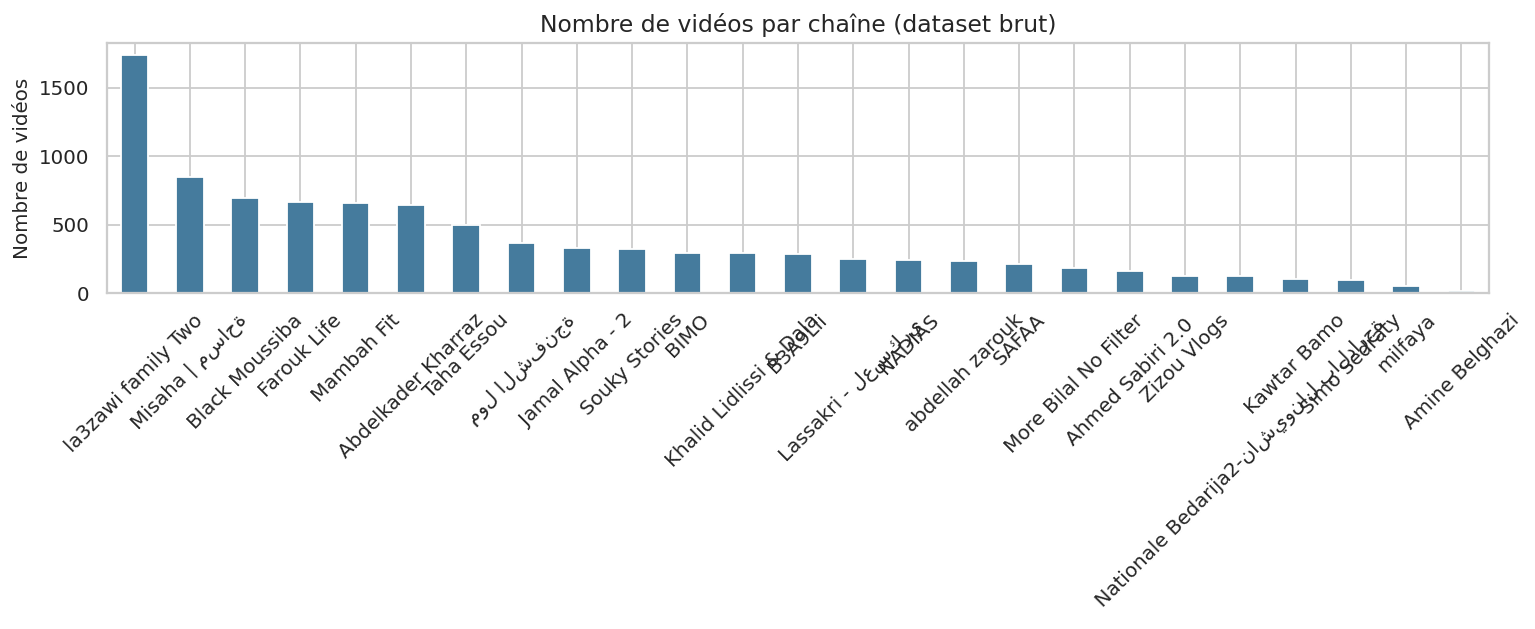

In [47]:
channel_counts = df_raw['channelTitle'].value_counts()
print(f"Vidéos par chaîne : min={channel_counts.min()}, max={channel_counts.max()}, médiane={channel_counts.median():.0f}")

fig, ax = plt.subplots(figsize=(12, 5))
channel_counts.plot(kind='bar', ax=ax, color=BLUE, edgecolor='white')
ax.set_title('Nombre de vidéos par chaîne (dataset brut)')
ax.set_xlabel('')
ax.set_ylabel('Nombre de vidéos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 2.4 — Distribution brute des vues (détection outliers)

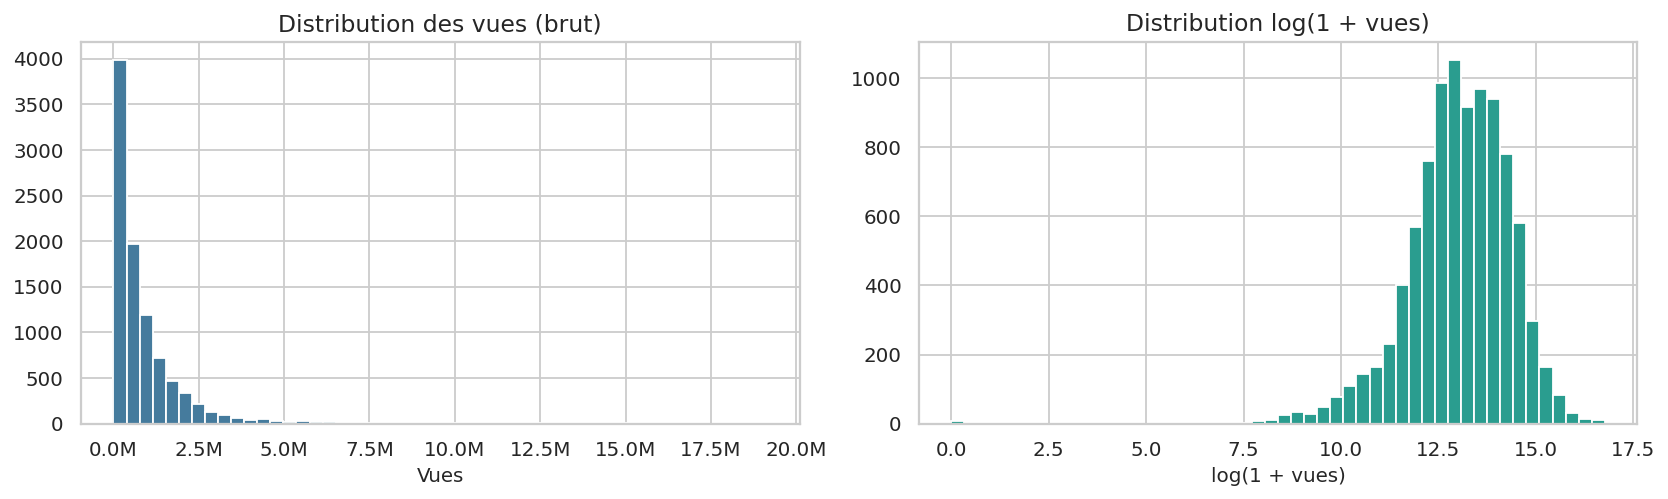

99e percentile des vues : 5,793,605
Vidéos > 10M vues : 23
Médiane : 489,492 | Moyenne : 895,814


In [48]:
views = df_raw['viewCount'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(views, bins=50, color=BLUE, edgecolor='white')
axes[0].set_title('Distribution des vues (brut)')
axes[0].set_xlabel('Vues')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].hist(np.log1p(views), bins=50, color=GREEN, edgecolor='white')
axes[1].set_title('Distribution log(1 + vues)')
axes[1].set_xlabel('log(1 + vues)')

plt.tight_layout()
plt.show()

q99 = views.quantile(0.99)
print(f"99e percentile des vues : {q99:,.0f}")
print(f"Vidéos > 10M vues : {(views > 10_000_000).sum()}")
print(f"Médiane : {views.median():,.0f} | Moyenne : {views.mean():,.0f}")

## 3. Nettoyage
### 3.1 — Suppression des colonnes inutiles

In [49]:
df = df_raw.copy()

# Colonnes jamais renseignées ou sans valeur analytique
cols_drop = [
    'dislikeCount',          # inaccessible via l'API YouTube depuis 2021
    'hasPaidProductPlacement',  # 99.8% vide
    'locationDescription',   # 98.4% vide
    'latitude', 'longitude', # idem
    'thumbnail_maxres',      # URL inutile pour l'analyse
    'favoriteCount',         # toujours 0 depuis 2012
    'publishedAt',           # doublon de publishedAtSQL
]
df.drop(columns=[c for c in cols_drop if c in df.columns], inplace=True)
print(f"✅ Colonnes restantes : {df.shape[1]} (supprimé {len([c for c in cols_drop if c in df_raw.columns])})")

✅ Colonnes restantes : 22 (supprimé 8)


### 3.2 — Suppression de la ligne totalement vide

In [50]:
# 1 ligne où channelTitle, videoTitle, viewCount… sont tous NaN → scraping raté
n_before = len(df)
df.dropna(subset=['channelTitle', 'videoId'], inplace=True)
print(f"Lignes supprimées (identité manquante) : {n_before - len(df)}")

Lignes supprimées (identité manquante) : 1


### 3.3 — Gestion des valeurs manquantes
> **Principe :** on ne fait pas de `fillna(0)` systématique sur les métriques.  
> Un `likeCount` manquant ≠ 0 likes ; on le laisse NaN pour les analyses d'engagement.

In [51]:
# Texte → chaîne vide (NaN ici est sans ambiguïté)
df['tags'] = df['tags'].fillna('')
df['videoDescription'] = df['videoDescription'].fillna('')
df['topicCategories'] = df['topicCategories'].fillna('Unknown')

# licensedContent : booléen → 0/1 (NaN → 0 acceptable car valeur par défaut API)
df['licensedContent'] = df['licensedContent'].fillna(0).astype(int)

# likeCount / commentCount : on laisse NaN
# viewCount : on supprime les 8 lignes à 0 (vidéos inaccessibles)
df = df[df['viewCount'] > 0]

print(f"✅ Dataset nettoyé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print("Valeurs manquantes restantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

✅ Dataset nettoyé : 9,440 lignes × 22 colonnes
Valeurs manquantes restantes :
likeCount       23
commentCount    24
dtype: int64


### 3.4 — Typage correct

In [52]:
df['publishedAtSQL'] = pd.to_datetime(df['publishedAtSQL'], utc=True)
df['viewCount']      = df['viewCount'].astype(int)
df['durationSec']    = df['durationSec'].astype(int)
# videoCategoryId peut rester float (certaines vidéos sans catégorie)

print("✅ Types corrigés :")
print(df[['publishedAtSQL','viewCount','durationSec']].dtypes)

✅ Types corrigés :
publishedAtSQL    datetime64[ns, UTC]
viewCount                       int64
durationSec                     int64
dtype: object


## 4. Feature Engineering
On crée uniquement les variables avec une utilité analytique démontrée.

In [53]:
# ── Variables temporelles ──────────────────────────────────────────────────
df['publish_hour']    = df['publishedAtSQL'].dt.hour
df['publish_day']     = df['publishedAtSQL'].dt.day_name()
df['publish_dow']     = df['publishedAtSQL'].dt.dayofweek   # 0=Lundi
df['publish_year']    = df['publishedAtSQL'].dt.year
df['is_weekend']      = df['publish_dow'].isin([4, 5, 6]).astype(int)
# Vendredi inclus = week-end culturel au Maroc

# ── Format ────────────────────────────────────────────────────────────────
df['is_short']        = (df['durationSec'] <= 60).astype(int)
df['duration_min']    = (df['durationSec'] / 60).round(1)

# ── Engagement (calculé uniquement quand les deux métriques sont disponibles)
df['engagement_rate'] = (
    (df['likeCount'].fillna(0) + df['commentCount'].fillna(0))
    / df['viewCount']
)
df['like_ratio']      = df['likeCount'] / df['viewCount']

# ── Titre ─────────────────────────────────────────────────────────────────
df['title_word_count'] = df['videoTitle'].astype(str).str.split().str.len()
# Tags : séparateur virgule dans ce dataset
df['tags_count']       = df['tags'].apply(
    lambda x: len([t.strip() for t in x.split(',') if t.strip()]) if x else 0
)

print(f"✅ Features créées. Colonnes finales : {df.shape[1]}")
print(df[['is_short','engagement_rate','like_ratio','tags_count','title_word_count']].describe().round(4))

✅ Features créées. Colonnes finales : 33
       is_short  engagement_rate  like_ratio  tags_count  title_word_count
count    9440.0        9440.0000   9417.0000   9440.0000         9440.0000
mean        0.1           0.0517      0.0493     14.8317           10.1179
std         0.3           0.0315      0.0298     14.6346            3.4665
min         0.0           0.0001      0.0007      0.0000            1.0000
25%         0.0           0.0298      0.0281      0.0000            8.0000
50%         0.0           0.0452      0.0430     11.0000           10.0000
75%         0.0           0.0645      0.0616     25.0000           12.0000
max         1.0           0.3049      0.2799     60.0000           22.0000


In [54]:
df

,position,channelId,channelTitle,videoId,publishedAtSQL,videoTitle,videoDescription,tags,videoCategoryId,videoCategoryLabel,...,publish_day,publish_dow,publish_year,is_weekend,is_short,duration_min,engagement_rate,like_ratio,title_word_count,tags_count
0,1,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,zgAe3cqZVCE,2026-04-15 17:35:32+00:00,طوب 5 | غرائب الجامعات المغربية 🤣🤣,kick: https://kick.com/zaroukabdellah For busi...,,23.0,Comedy,...,Wednesday,2,2026,0,0,46.6,0.033512,0.031278,7,0
1,2,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,u6avr_4SEd4,2026-03-23 17:16:32+00:00,طوب 5 | أغرب فتاوى مغربية 🤣🤣,يسلط عبد الله زروق الضوء على فتاوى دينية مغربي...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,Comedy,...,Monday,0,2026,0,0,6.7,0.033259,0.030395,7,53
2,3,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,BxeiTEQ_Og4,2026-02-25 21:20:38+00:00,طوب 5 | غرائب رياضية 🤣🤣,قناتي الخاصة بالألعاب: https://www.youtube.com...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,Comedy,...,Wednesday,2,2026,0,0,38.5,0.033080,0.031503,6,53
3,4,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,RO9N2JgaOeg,2026-02-17 22:24:47+00:00,طوب 5 | أغرب مقالب مغربية 🤣🤣,يستعرض عبد الله زروق تطور مقالب وسائل التواصل ...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,Comedy,...,Tuesday,1,2026,0,0,20.2,0.032305,0.030779,7,53
4,5,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,4IDvvncwJvU,2026-01-20 18:08:10+00:00,باريس لا تستحق 🤣🤣,قناتي الخاصة بالألعاب: https://www.youtube.com...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,Comedy,...,Tuesday,1,2026,0,0,12.6,0.047358,0.044894,4,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9443,121,UChOoQb2-j2adGHoi-OPxQQQ,Zizou Vlogs,_lt_Ss0Vs4k,2020-11-21 19:22:35+00:00,مشيت للقرية الساحرة 😍وخلقناها معا مريكانيات ال...,Aتابعوني على تطبيق YouNow كل يوم بث ⬇️ https:/...,"Bimo,Koulchi,Abdellah zarrouk,Jamal alpha,Zoz ...",22.0,People & Blogs,...,Saturday,5,2020,1,0,26.7,0.031091,0.029463,12,26
9444,122,UChOoQb2-j2adGHoi-OPxQQQ,Zizou Vlogs,3eQfAJMIwUQ,2020-11-13 17:30:19+00:00,مشيت لجزيرة النساء وخلقنا السعادة معا تيتيز ال...,تابعوني على تطبيق YouNow كل يوم بث ⬇️ https://...,"Zizou vlogs,Hamada chroukate,Fayssal vlog,Fays...",22.0,People & Blogs,...,Friday,4,2020,1,0,21.4,0.030939,0.029254,14,24
9445,123,UChOoQb2-j2adGHoi-OPxQQQ,Zizou Vlogs,GbhCqxcNbxQ,2020-11-09 19:13:48+00:00,حياة الليل فلاس فيغاس ديال المكسيك 😱 | Mexico ...,Aتابعوني على الانستغرام FOLLOW ME ON INSTAGRAM...,"Hassan diae vlogs,Mourad Mzouri vlogs,Aymane s...",22.0,People & Blogs,...,Monday,0,2020,0,0,22.2,0.034576,0.032337,11,24
9447,125,UChOoQb2-j2adGHoi-OPxQQQ,Zizou Vlogs,o9dYvTlsihE,2020-08-11 14:41:53+00:00,درت مشروع ديال الهندية فالمكسيك بزيرو درهم شوف...,MY INSTAGRAM : zizouvlogs هدا الانستغرام ديال ...,"hassan diae vlogs,taha essou,niba tbib,hamada ...",22.0,People & Blogs,...,Tuesday,1,2020,0,0,33.8,0.037034,0.033490,13,21


## 5. EDA Business

### 5.1 — Distribution des vues par format (Shorts vs Long)

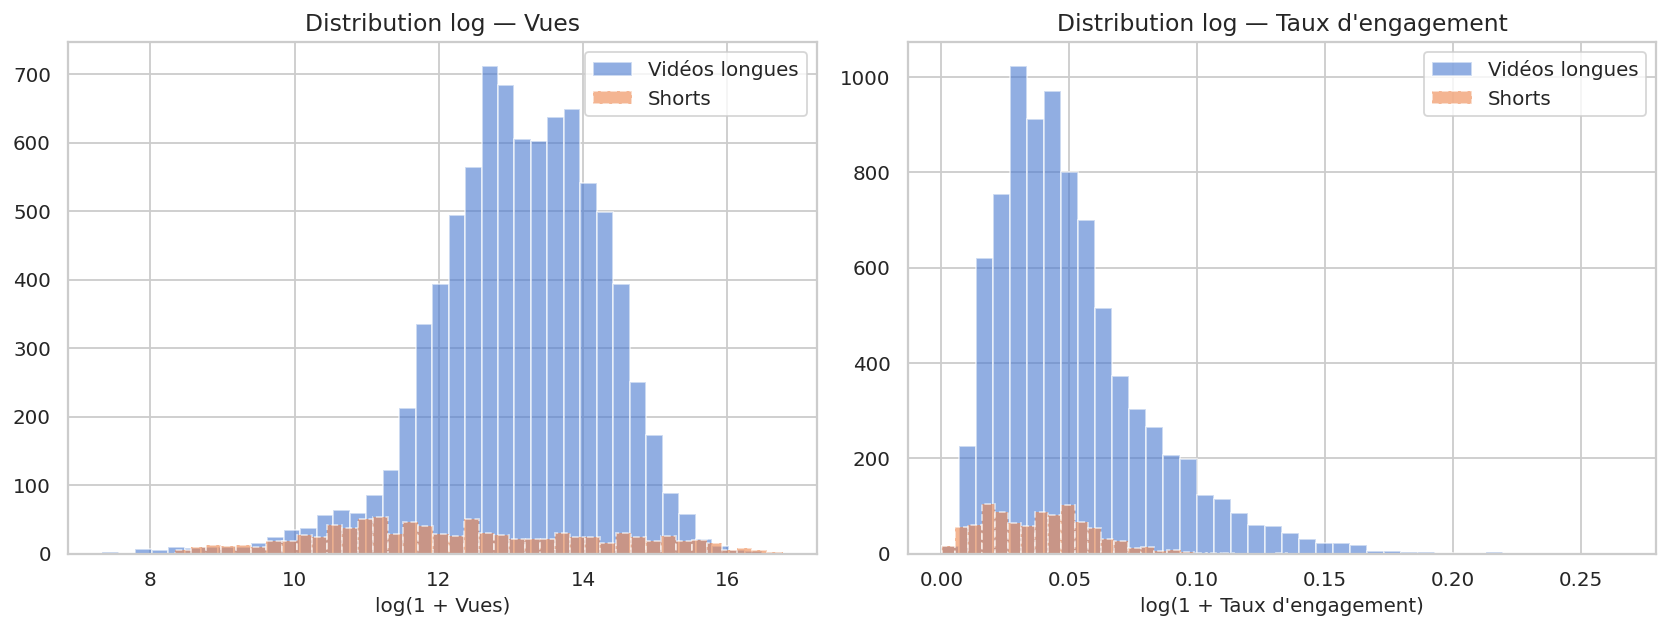

=== Vues médianes par format ===
            median          mean  count
is_short                               
Long      514905.5  8.646100e+05   8496
Short     181975.0  1.184244e+06    944


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label, color in zip(
    axes,
    ['viewCount', 'engagement_rate'],
    ['Vues', 'Taux d\'engagement'],
    [BLUE, GREEN]
):
    for fmt, ls in [(0, '-'), (1, '--')]:
        subset = df[df['is_short'] == fmt][col].dropna()
        label_fmt = 'Shorts' if fmt else 'Vidéos longues'
        ax.hist(np.log1p(subset), bins=40, alpha=0.6, label=label_fmt, linestyle=ls)
    ax.set_xlabel(f'log(1 + {label})')
    ax.set_title(f'Distribution log — {label}')
    ax.legend()

plt.tight_layout()
plt.show()

print("=== Vues médianes par format ===")
print(df.groupby('is_short')['viewCount'].agg(['median','mean','count']).rename(index={0:'Long',1:'Short'}))

### 5.2 — Shorts vs Vidéos Longues : comparaison directe

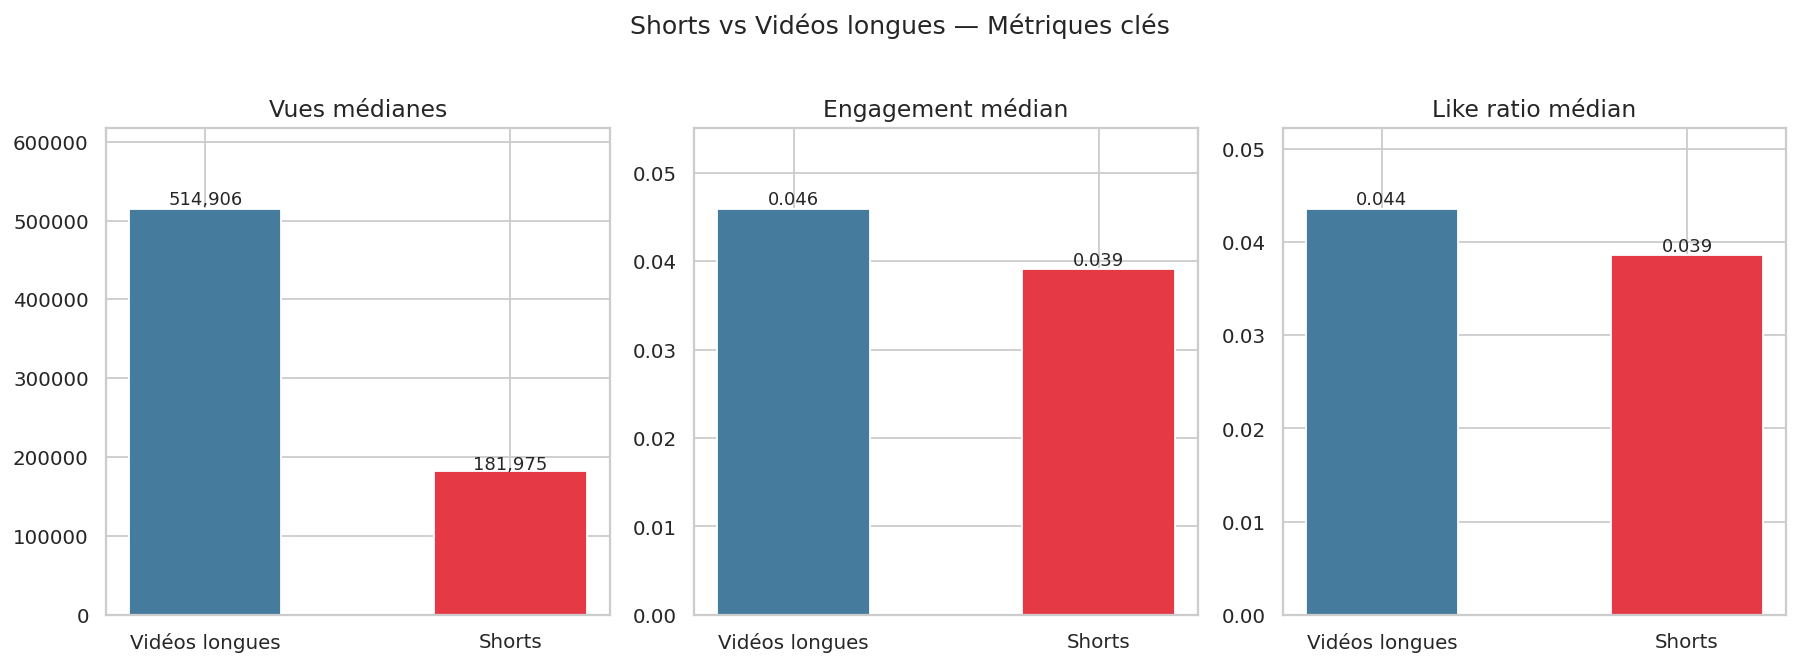

Mann-Whitney U (vues Long vs Short) : p = 0.0000
→ Différence statistiquement significative


In [56]:
metrics = {
    'Vues médianes': df.groupby('is_short')['viewCount'].median(),
    'Engagement médian': df.groupby('is_short')['engagement_rate'].median(),
    'Like ratio médian': df.groupby('is_short')['like_ratio'].median(),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (title, series) in zip(axes, metrics.items()):
    vals = [series.get(0, 0), series.get(1, 0)]
    bars = ax.bar(['Vidéos longues', 'Shorts'], vals, color=[BLUE, RED], edgecolor='white', width=0.5)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:,.3f}' if v < 1 else f'{v:,.0f}', ha='center', fontsize=10)
    ax.set_ylim(0, max(vals)*1.2)

plt.suptitle('Shorts vs Vidéos longues — Métriques clés', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Test statistique rapide
from scipy import stats
long_views = df[df['is_short']==0]['viewCount'].dropna()
short_views = df[df['is_short']==1]['viewCount'].dropna()
stat, pval = stats.mannwhitneyu(long_views, short_views, alternative='two-sided')
print(f"Mann-Whitney U (vues Long vs Short) : p = {pval:.4f}")
print("→ Différence statistiquement significative" if pval < 0.05 else "→ Pas de différence significative")

### 5.3 — Prime Time : Meilleur jour et meilleure heure de publication

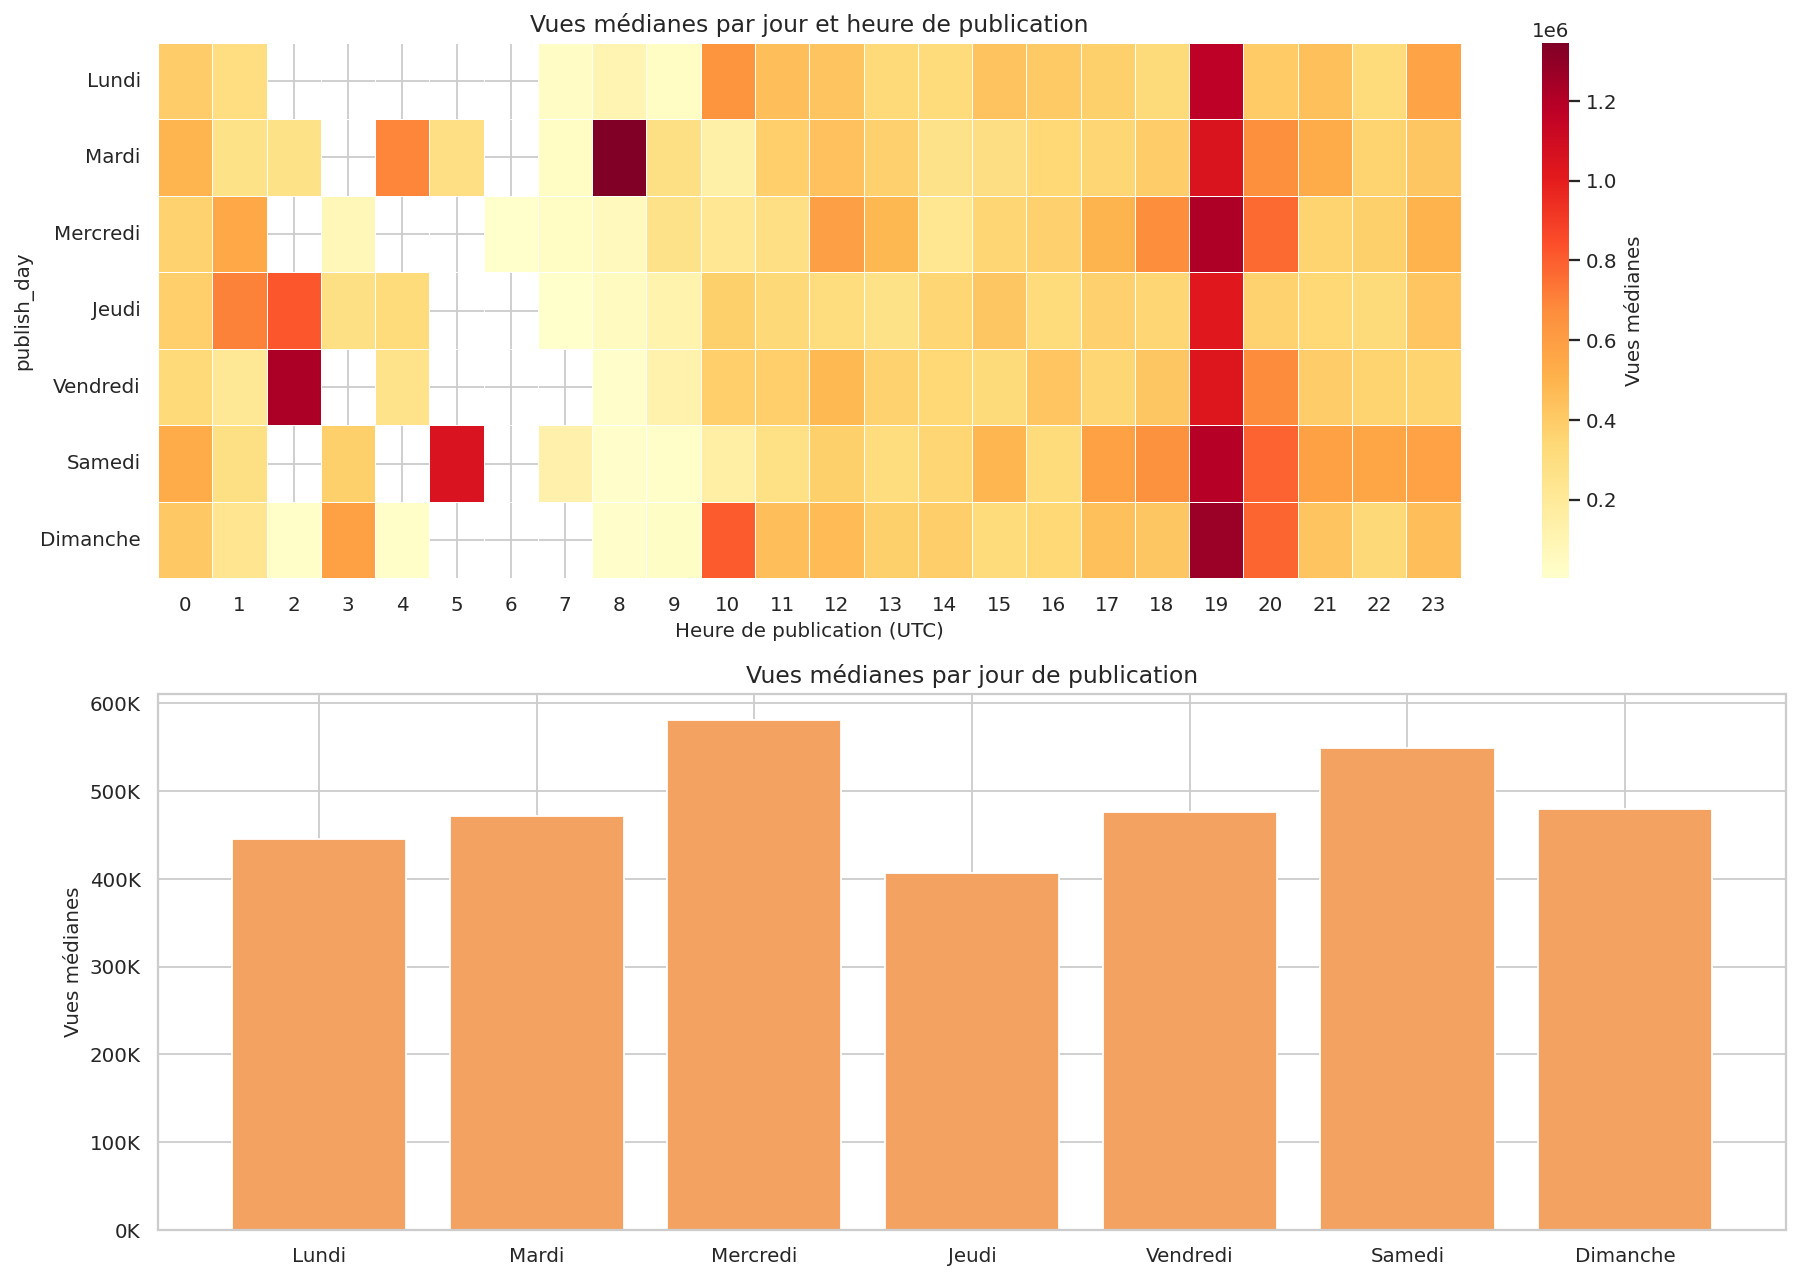


🏆 Top 5 créneaux de publication (vues médianes) :
publish_day  publish_hour
Tuesday      8               1346063.0
Sunday       19              1269008.0
Friday       2               1224133.0
Wednesday    19              1217771.0
Saturday     19              1190121.0
Name: viewCount, dtype: float64


In [57]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# solution robuste
df['publish_day'] = df['publishedAtSQL'].dt.dayofweek.map({
    0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',
    4:'Friday',5:'Saturday',6:'Sunday'
})

df['publish_hour'] = df['publishedAtSQL'].dt.hour

pivot = df.pivot_table(
    values='viewCount',
    index='publish_day',
    columns='publish_hour',
    aggfunc='median'
)

pivot = pivot.reindex(day_order)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Heatmap
sns.heatmap(
    pivot, ax=axes[0], cmap='YlOrRd',
    fmt='.0f', linewidths=0.3,
    cbar_kws={'label': 'Vues médianes'}
)
axes[0].set_title('Vues médianes par jour et heure de publication')
axes[0].set_yticklabels(day_fr, rotation=0)
axes[0].set_xlabel('Heure de publication (UTC)')

# Bar chart par jour
day_views = (df.groupby(
    pd.Categorical(df['publish_day'], categories=day_order, ordered=True)
)['viewCount'].median()).reset_index()
day_views.columns = ['day','views']

axes[1].bar(day_fr, day_views['views'], color=ORANGE, edgecolor='white')
axes[1].set_title('Vues médianes par jour de publication')
axes[1].set_ylabel('Vues médianes')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

# Top 3 créneaux horaires
top_slots = df.groupby(['publish_day','publish_hour'])['viewCount'].median().nlargest(5)
print("\n🏆 Top 5 créneaux de publication (vues médianes) :")
print(top_slots)

## 6. Agrégation et comparaison par chaîne

In [58]:
channel_agg = df.groupby('channelTitle').agg(
    nb_videos       = ('videoId', 'count'),
    views_median    = ('viewCount', 'median'),
    views_mean      = ('viewCount', 'mean'),
    engagement_med  = ('engagement_rate', 'median'),
    like_ratio_med  = ('like_ratio', 'median'),
    duration_med    = ('duration_min', 'median'),
    pct_shorts      = ('is_short', 'mean'),
    tags_count_med  = ('tags_count', 'median'),
).reset_index()

channel_agg['pct_shorts'] = (channel_agg['pct_shorts'] * 100).round(1)
channel_agg = channel_agg.sort_values('views_median', ascending=False)

print(channel_agg[['channelTitle','nb_videos','views_median','engagement_med','pct_shorts']].to_string(index=False))

                           channelTitle  nb_videos  views_median  engagement_med  pct_shorts
                     la3zawi family Two       1741     1672441.0        0.022345        10.3
                                  SAFAA        213     1632391.0        0.047116         0.0
                            Kawtar Bamo        102     1074904.5        0.035324        24.5
                     Abdelkader Kharraz        645      988122.0        0.032004         2.0
                                   BIMO        296      796846.0        0.062813         0.3
                           Simo Sedraty         94      761633.5        0.044007        16.0
                     Lassakri - لعسكري         247      692823.0        0.037275         0.8
                 Khalid Lidlissi & Dala        295      622217.0        0.063611         1.7
                         Misaha | مساحة        844      600675.0        0.081374        10.1
 Nationale Bedarija2-ناشيونال بالدارجة         124      513431.0      

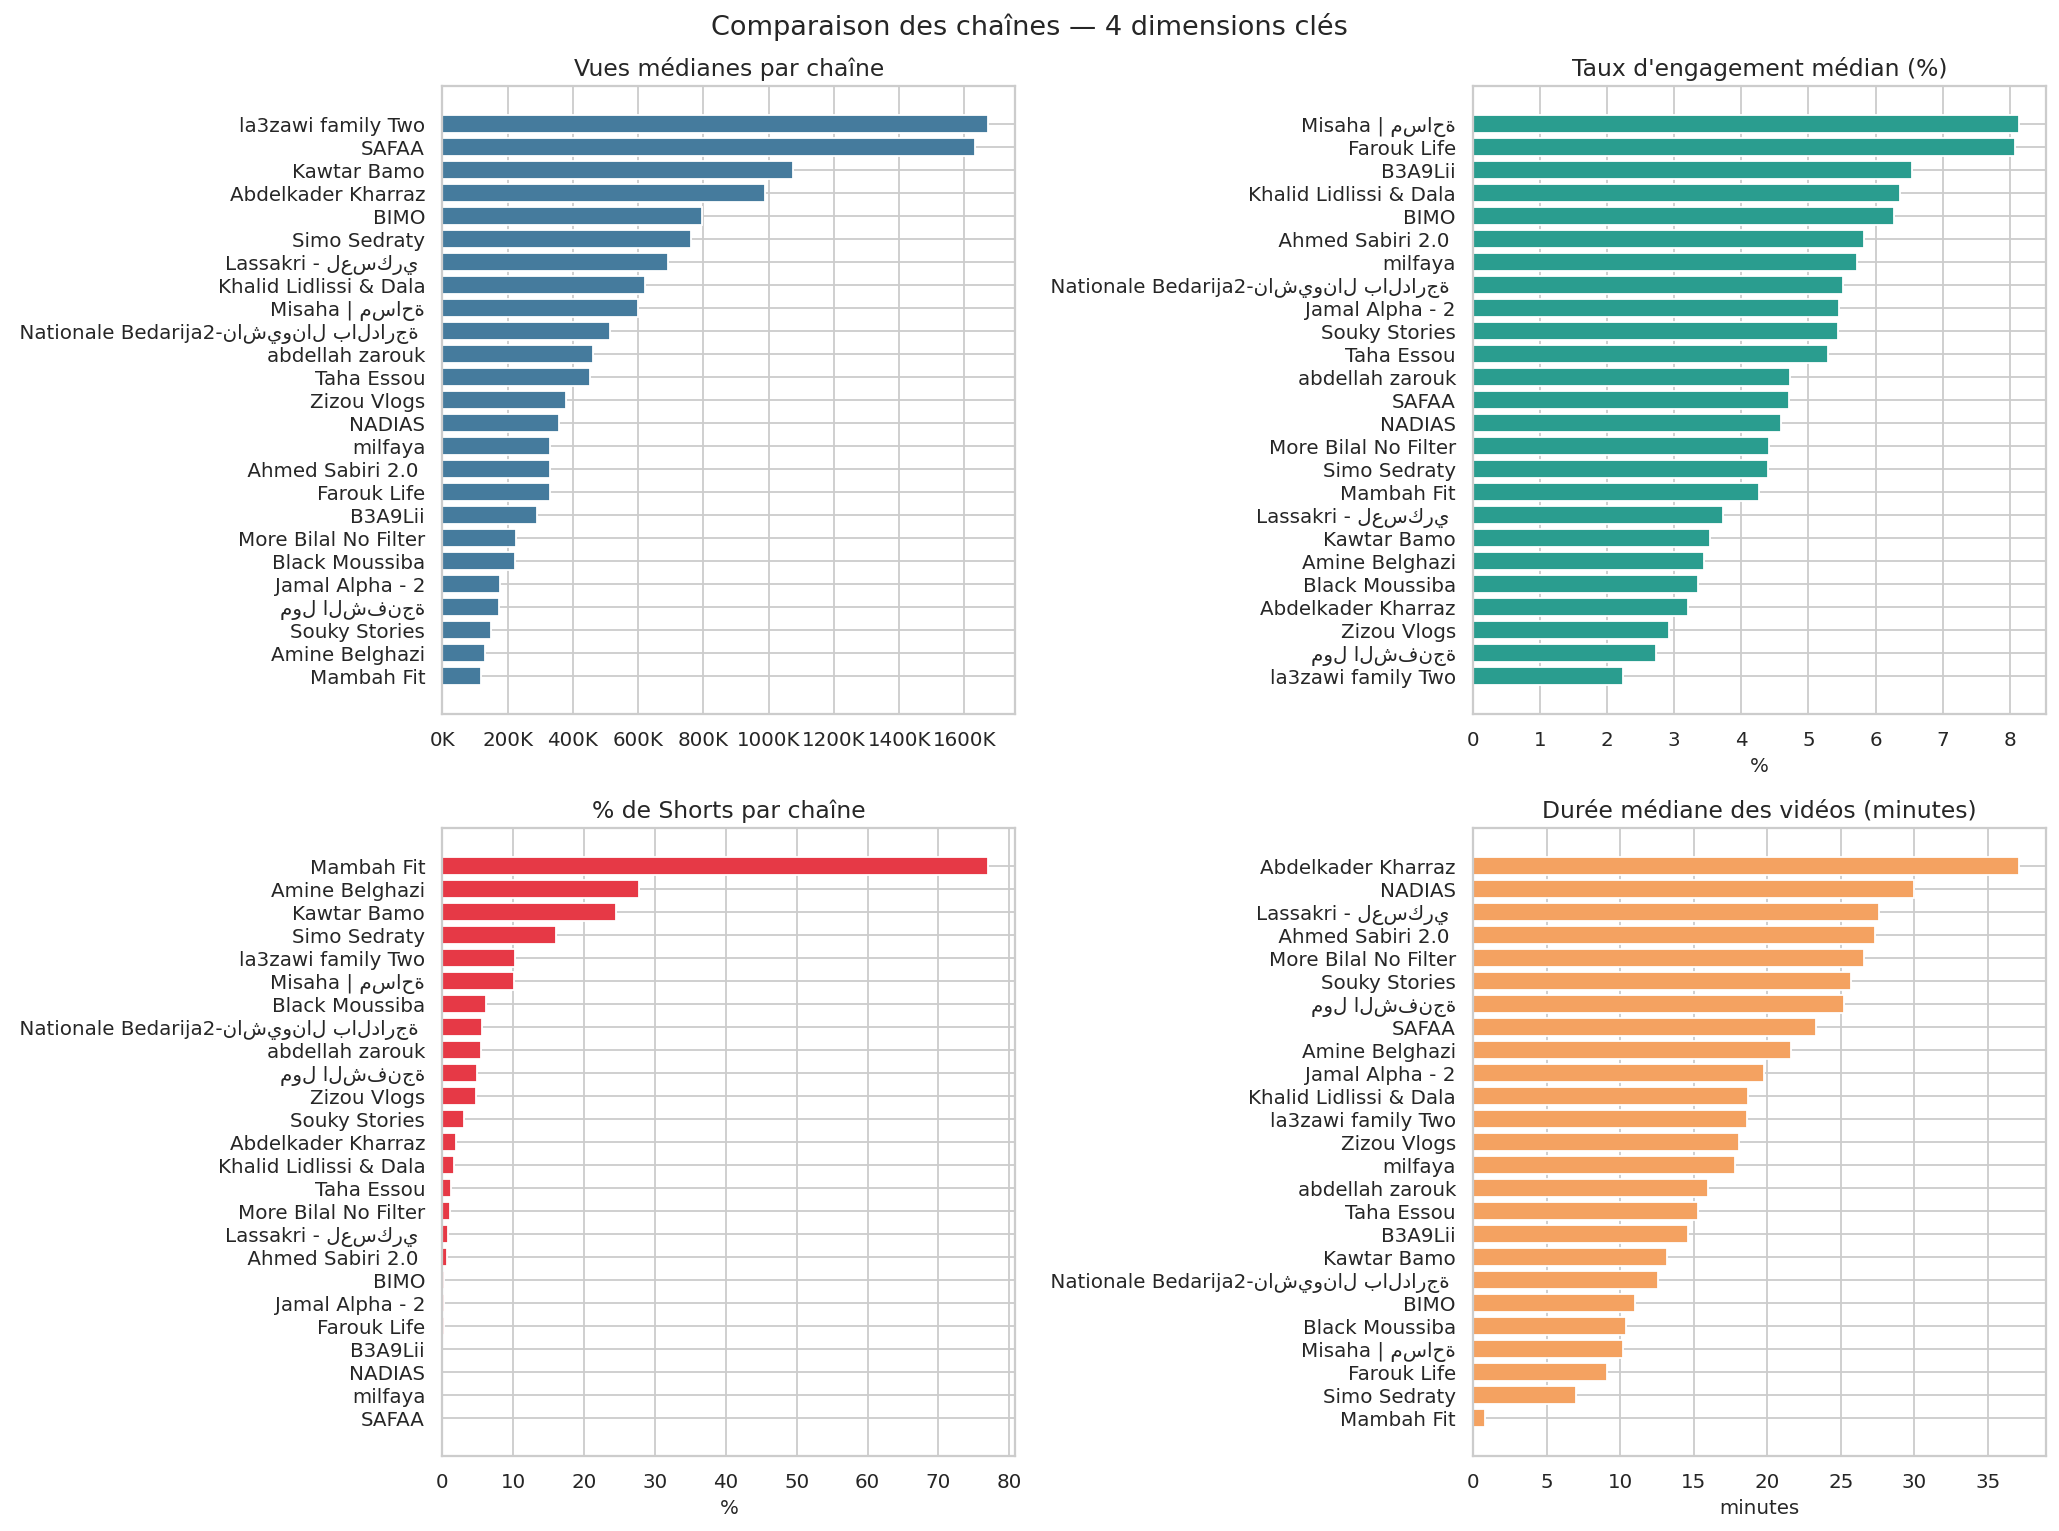

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Vues médianes
ax = axes[0,0]
sorted_ch = channel_agg.sort_values('views_median')
ax.barh(sorted_ch['channelTitle'], sorted_ch['views_median'], color=BLUE, edgecolor='white')
ax.set_title('Vues médianes par chaîne')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

# 2. Engagement médian
ax = axes[0,1]
sorted_ch2 = channel_agg.sort_values('engagement_med')
ax.barh(sorted_ch2['channelTitle'], sorted_ch2['engagement_med']*100, color=GREEN, edgecolor='white')
ax.set_title('Taux d\'engagement médian (%)')
ax.set_xlabel('%')

# 3. % Shorts
ax = axes[1,0]
sorted_ch3 = channel_agg.sort_values('pct_shorts')
ax.barh(sorted_ch3['channelTitle'], sorted_ch3['pct_shorts'], color=RED, edgecolor='white')
ax.set_title('% de Shorts par chaîne')
ax.set_xlabel('%')

# 4. Durée médiane
ax = axes[1,1]
sorted_ch4 = channel_agg.sort_values('duration_med')
ax.barh(sorted_ch4['channelTitle'], sorted_ch4['duration_med'], color=ORANGE, edgecolor='white')
ax.set_title('Durée médiane des vidéos (minutes)')
ax.set_xlabel('minutes')

plt.suptitle('Comparaison des chaînes — 4 dimensions clés', fontsize=15)
plt.tight_layout()
plt.show()

## 7. Segmentation des chaînes — K-Means
On identifie des profils de créateurs selon : vues, engagement, mix de formats et cadence.

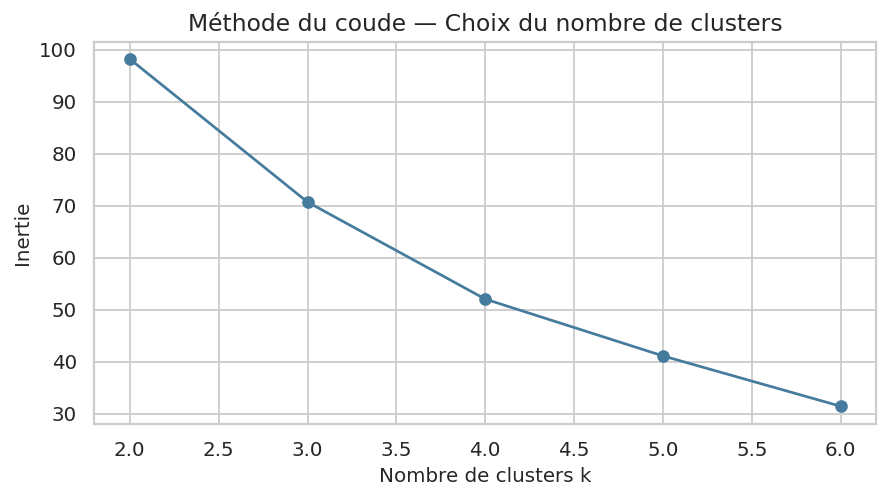

In [61]:
features_cluster = ['views_median','engagement_med','pct_shorts','duration_med','nb_videos']
X_raw = channel_agg[features_cluster].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Choix du k via inertie (elbow)
inertias = []
K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'o-', color=BLUE)
ax.set_title('Méthode du coude — Choix du nombre de clusters')
ax.set_xlabel('Nombre de clusters k')
ax.set_ylabel('Inertie')
plt.tight_layout()
plt.show()

In [63]:
K_OPTIMAL = 4   # ajustable selon le coude observé

km = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
channel_agg['cluster'] = km.fit_predict(X_scaled)

# Profil moyen de chaque cluster
cluster_profile = channel_agg.groupby('cluster')[features_cluster].mean().round(2)
cluster_profile.index = [f'Segment {i}' for i in cluster_profile.index]
print("\n=== Profil moyen des segments ===")
print(cluster_profile.to_string())


=== Profil moyen des segments ===
           views_median  engagement_med  pct_shorts  duration_med  nb_videos
Segment 0     505684.50            0.04        4.51         26.25     252.80
Segment 1    1672441.00            0.02       10.30         18.60    1741.00
Segment 2     117119.00            0.04       77.00          0.80     656.00
Segment 3     510004.31            0.06        5.51         13.52     347.31


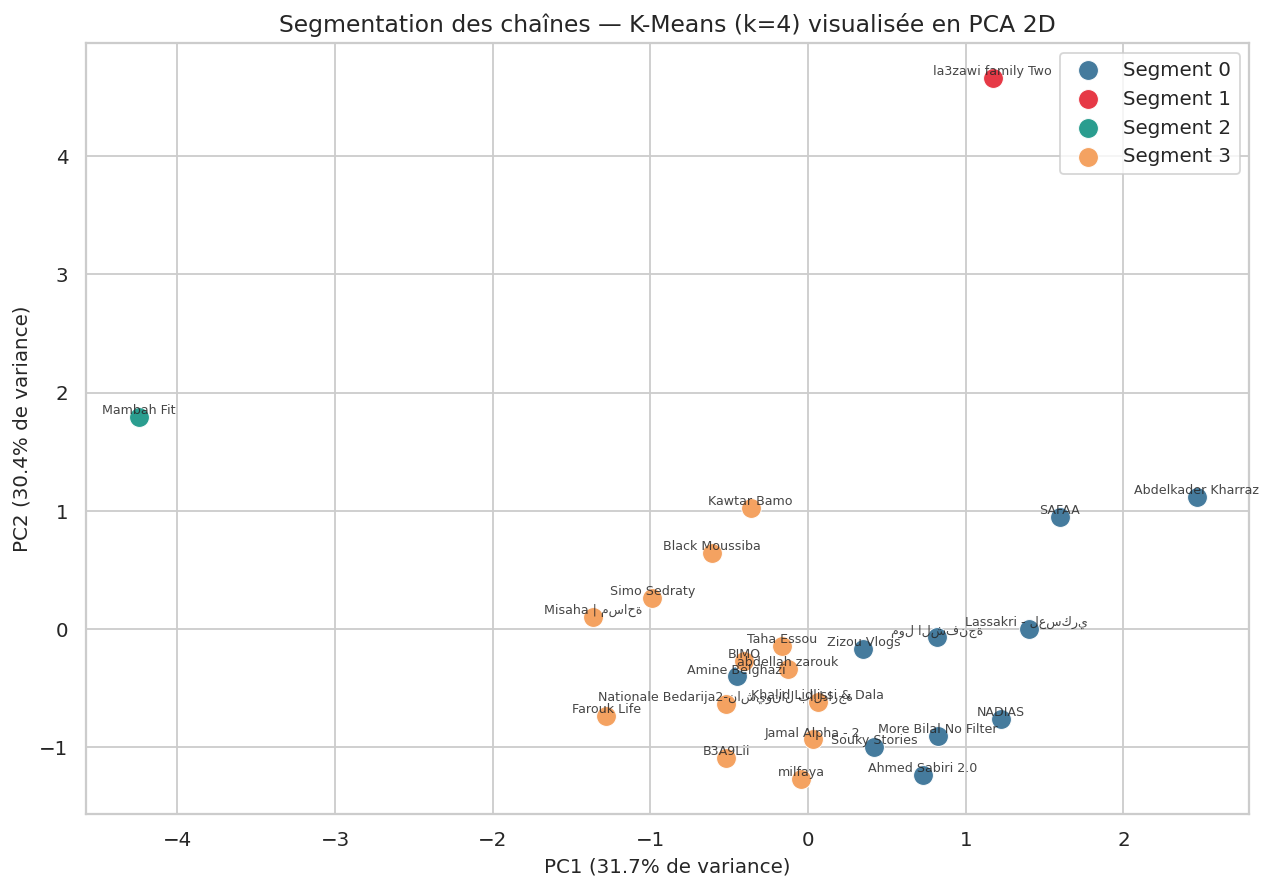

In [64]:
# PCA 2D pour visualisation
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
channel_agg['pca1'] = coords[:,0]
channel_agg['pca2'] = coords[:,1]

palette = {0: BLUE, 1: RED, 2: GREEN, 3: ORANGE}
fig, ax = plt.subplots(figsize=(10, 7))
for seg, grp in channel_agg.groupby('cluster'):
    ax.scatter(grp['pca1'], grp['pca2'],
               c=palette[seg], label=f'Segment {seg}', s=120, edgecolors='white', linewidths=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row['channelTitle'], (row['pca1'], row['pca2']),
                    fontsize=7, ha='center', va='bottom', alpha=0.85)

ax.set_title(f'Segmentation des chaînes — K-Means (k={K_OPTIMAL}) visualisée en PCA 2D')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)')
ax.legend()
plt.tight_layout()
plt.show()

In [65]:
# Listing des chaînes par segment
for seg, grp in channel_agg.sort_values('cluster').groupby('cluster'):
    print(f"\n📂 Segment {seg} ({len(grp)} chaînes)")
    print(grp[['channelTitle','views_median','engagement_med','pct_shorts','nb_videos']].to_string(index=False))


📂 Segment 0 (10 chaînes)
        channelTitle  views_median  engagement_med  pct_shorts  nb_videos
               SAFAA     1632391.0        0.047116         0.0        213
  Abdelkader Kharraz      988122.0        0.032004         2.0        645
  Lassakri - لعسكري       692823.0        0.037275         0.8        247
              NADIAS      358253.5        0.045878         0.0        240
   Ahmed Sabiri 2.0       328702.0        0.058262         0.6        163
         Zizou Vlogs      378852.0        0.029194         4.8        125
      Amine Belghazi      132327.5        0.034390        27.8         18
More Bilal No Filter      224439.0        0.044170         1.1        185
         مول الشفنجة      172941.5        0.027293         4.9        366
       Souky Stories      147993.5        0.054356         3.1        326

📂 Segment 1 (1 chaînes)
      channelTitle  views_median  engagement_med  pct_shorts  nb_videos
la3zawi family Two     1672441.0        0.022345        10.3   

## 8. Synthèse & Recommandations Stratégiques

> Ce bloc interprète les résultats de l'analyse. À ajuster après exécution complète.

In [66]:
# ── Calcul des chiffres clés pour la synthèse ─────────────────────────────
view_med_long  = df[df['is_short']==0]['viewCount'].median()
view_med_short = df[df['is_short']==1]['viewCount'].median()
eng_long       = df[df['is_short']==0]['engagement_rate'].median()
eng_short      = df[df['is_short']==1]['engagement_rate'].median()

top_day = (df.groupby('publish_day')['viewCount'].median()
             .reindex(day_order).idxmax())
top_hour_series = df.groupby('publish_hour')['viewCount'].median()
top_hour = top_hour_series.idxmax()

top_channel = channel_agg.sort_values('views_median', ascending=False).iloc[0]

print("=" * 60)
print("   SYNTHÈSE — BENCHMARK YOUTUBE MAROC")
print("=" * 60)
print(f"\n📊 Dataset : {len(df):,} vidéos | {df['channelTitle'].nunique()} chaînes")
print(f"   Période  : {df['publishedAtSQL'].dt.year.min()} – {df['publishedAtSQL'].dt.year.max()}")

print("\n🎬 FORMAT")
print(f"   Shorts ({(df['is_short'].mean()*100):.1f}% du corpus)")
print(f"   → Vues médianes Long : {view_med_long:,.0f} | Short : {view_med_short:,.0f}")
ratio = view_med_long/view_med_short if view_med_short > 0 else 0
print(f"   → Les vidéos longues génèrent {ratio:.1f}× plus de vues en médiane")
print(f"   → L'engagement est {'plus élevé' if eng_short > eng_long else 'moins élevé'} sur les Shorts")

print("\n🕐 PRIME TIME")
print(f"   Meilleur jour  : {top_day}")
print(f"   Meilleure heure : {top_hour}h00 UTC")

print("\n🏆 CHAÎNE LA PLUS PERFORMANTE")
print(f"   {top_channel['channelTitle']} : {top_channel['views_median']:,.0f} vues médianes")

print("\n🔑 RECOMMANDATIONS STRATÉGIQUES")
print("   1. Privilégier les vidéos longues (10–30 min) pour la portée")
print("   2. Tester les Shorts pour maximiser l'engagement et la découverte")
print(f"   3. Publier le {top_day} autour de {top_hour}h UTC")
print("   4. Utiliser 10–20 tags pertinents (qualité > quantité)")
print("   5. Maintenir une cadence régulière (signal fort pour l'algorithme)")
print("\n✅ Analyse terminée.")

   SYNTHÈSE — BENCHMARK YOUTUBE MAROC

📊 Dataset : 9,440 vidéos | 25 chaînes
   Période  : 2012 – 2026

🎬 FORMAT
   Shorts (10.0% du corpus)
   → Vues médianes Long : 514,906 | Short : 181,975
   → Les vidéos longues génèrent 2.8× plus de vues en médiane
   → L'engagement est moins élevé sur les Shorts

🕐 PRIME TIME
   Meilleur jour  : Wednesday
   Meilleure heure : 19h00 UTC

🏆 CHAÎNE LA PLUS PERFORMANTE
   la3zawi family Two : 1,672,441 vues médianes

🔑 RECOMMANDATIONS STRATÉGIQUES
   1. Privilégier les vidéos longues (10–30 min) pour la portée
   2. Tester les Shorts pour maximiser l'engagement et la découverte
   3. Publier le Wednesday autour de 19h UTC
   4. Utiliser 10–20 tags pertinents (qualité > quantité)
   5. Maintenir une cadence régulière (signal fort pour l'algorithme)

✅ Analyse terminée.


---
## Annexe — Export du dataset nettoyé

In [ ]:
df.to_csv('yt_morocco_benchmark_cleaned.csv', index=False)
channel_agg.to_csv('yt_morocco_channel_profiles.csv', index=False)
print("✅ Fichiers exportés :")
print("   • yt_morocco_benchmark_cleaned.csv")
print("   • yt_morocco_channel_profiles.csv")